In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('capston_filled.csv')
df.head()

,Unnamed: 0,SEQID,PROVID,GRADE,DVGENDER,DVURBAN,DVRES,GH_010,GH_020,SS_010,...,BEH_010,BEH_020,BUL_010,BUL_020,BUL_030,BUL_040,DVTY1ST,DVTY2ST,DVLAST30,DVAMTSMK
0,0,18338.0,Prince Edward Island,9,2,1,3,2,3,2,...,1,1,2,1,2,2,3,7,2,0
1,1,16111.0,Quebec,10,1,1,1,3,3,2,...,3,4,2,2,2,2,3,7,2,0
2,2,20587.0,Newfoundland and Labrador,7,2,1,1,2,1,2,...,4,4,2,2,2,2,3,7,2,0
3,3,54568.0,Nova Scotia,8,2,2,1,4,5,2,...,4,4,1,2,2,2,3,7,2,0
4,4,401.0,Newfoundland and Labrador,7,1,2,1,2,3,2,...,4,4,2,2,2,2,3,7,2,0


In [ ]:
# prompt: normalize the variables

import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Assuming 'df' is your DataFrame and contains numerical columns you want to normalize
numerical_cols = df.select_dtypes(include=np.number).columns

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Now the numerical columns in the DataFrame 'df' are normalized between 0 and 1
df.head()


,Unnamed: 0,SEQID,PROVID,GRADE,DVGENDER,DVURBAN,DVRES,GH_010,GH_020,SS_010,...,BEH_010,BEH_020,BUL_010,BUL_020,BUL_030,BUL_040,DVTY1ST,DVTY2ST,DVLAST30,DVAMTSMK
0,0.000000,0.300151,Prince Edward Island,0.4,1.0,0.0,1.0,0.25,0.5,1.0,...,0.000000,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0
1,0.000016,0.263700,Quebec,0.6,0.0,0.0,0.0,0.50,0.5,1.0,...,0.666667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2,0.000033,0.336962,Newfoundland and Labrador,0.0,1.0,0.0,0.0,0.25,0.0,1.0,...,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
3,0.000049,0.893152,Nova Scotia,0.2,1.0,1.0,0.0,0.75,1.0,1.0,...,1.000000,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
4,0.000065,0.006563,Newfoundland and Labrador,0.0,0.0,1.0,0.0,0.25,0.5,1.0,...,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0


#Predict Smoking Behaviors

In [ ]:
# Select variables related to smoking: Provid2 to GH_020, SS_010, SS_020, TS_011, PH_010, PH_020, CA_020, BEH_010, BEH_020, BUL_010 to BUL040, DVTYIST, DVTY2ST, DVLAST3, DVAMTSMK
smoking_related_variables = ['PROVID', 'GRADE', 'DVGENDER', 'DVURBAN', 'DVRES', 'GH_010', 'GH_020', 'SS_010', 'SS_020', 'TS_011', 'PH_010', 'PH_020', 'CA_020', 'BEH_010', 'BEH_020', 'BUL_010', 'BUL_020', 'BUL_030', 'BUL_040', 'DVTY1ST', 'DVTY2ST', 'DVLAST30','DVAMTSMK']

# Create a new DataFrame with only the selected variables
df_smoking = df[smoking_related_variables]

# Display the new DataFrame
display(df_smoking.head())

,PROVID,GRADE,DVGENDER,DVURBAN,DVRES,GH_010,GH_020,SS_010,SS_020,TS_011,...,BEH_010,BEH_020,BUL_010,BUL_020,BUL_030,BUL_040,DVTY1ST,DVTY2ST,DVLAST30,DVAMTSMK
0,Prince Edward Island,0.4,1.0,0.0,1.0,0.25,0.5,1.0,0.114583,1.000000,...,0.000000,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0
1,Quebec,0.6,0.0,0.0,0.0,0.50,0.5,1.0,0.114583,1.000000,...,0.666667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2,Newfoundland and Labrador,0.0,1.0,0.0,0.0,0.25,0.0,1.0,0.114583,1.000000,...,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
3,Nova Scotia,0.2,1.0,1.0,0.0,0.75,1.0,1.0,0.114583,0.666667,...,1.000000,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
4,Newfoundland and Labrador,0.0,0.0,1.0,0.0,0.25,0.5,1.0,0.114583,1.000000,...,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0


In [ ]:
smoking_IV = ['PROVID', 'GRADE', 'DVGENDER', 'DVURBAN', 'DVRES', 'GH_010', 'GH_020', 'SS_020', 'PH_010', 'PH_020', 'CA_020', 'BEH_010', 'BEH_020', 'BUL_010', 'BUL_020', 'BUL_030', 'BUL_040']

# Create a new DataFrame with only the selected variables
smoking_IV = df[smoking_IV]

# Display the new DataFrame
display(smoking_IV.head())

,PROVID,GRADE,DVGENDER,DVURBAN,DVRES,GH_010,GH_020,SS_020,PH_010,PH_020,CA_020,BEH_010,BEH_020,BUL_010,BUL_020,BUL_030,BUL_040
0,Prince Edward Island,0.4,1.0,0.0,1.0,0.25,0.5,0.114583,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,1.0,1.0
1,Quebec,0.6,0.0,0.0,0.0,0.50,0.5,0.114583,0.333333,1.000000,1.000000,0.666667,1.0,1.0,1.0,1.0,1.0
2,Newfoundland and Labrador,0.0,1.0,0.0,0.0,0.25,0.0,0.114583,0.333333,0.666667,0.666667,1.000000,1.0,1.0,1.0,1.0,1.0
3,Nova Scotia,0.2,1.0,1.0,0.0,0.75,1.0,0.114583,0.333333,1.000000,0.666667,1.000000,1.0,0.0,1.0,1.0,1.0
4,Newfoundland and Labrador,0.0,0.0,1.0,0.0,0.25,0.5,0.114583,0.333333,0.333333,0.666667,1.000000,1.0,1.0,1.0,1.0,1.0


Predict Smoker or Non-Smoker (SS_010)

Accuracy of the logistic regression model: 0.719885433715221
Mean Squared Error: 0.28011456628477904


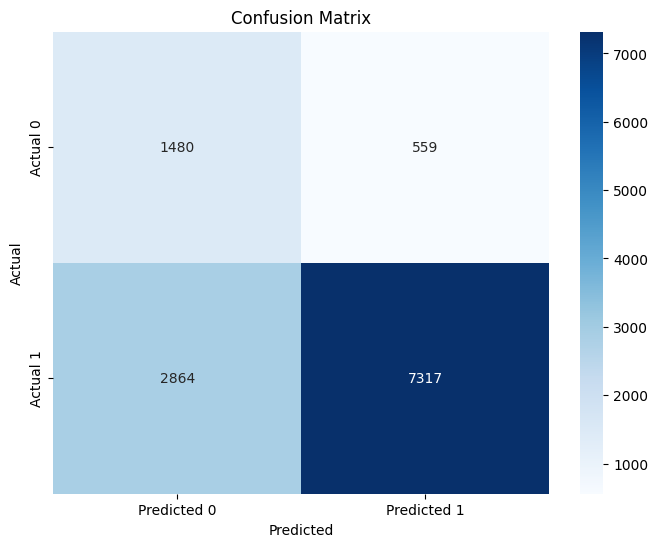

,Feature,Coefficient
0,GRADE,-2.023471
1,DVGENDER,-0.212662
2,DVURBAN,-0.437345
3,DVRES,0.129527
4,GH_010,-0.682174
5,GH_020,-1.083619
6,PH_010,1.737594
7,PH_020,-0.072605
8,CA_020,-1.667856
9,BEH_010,0.003874


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score


smoking_IV = ['PROVID', 'GRADE', 'DVGENDER', 'DVURBAN', 'DVRES', 'GH_010', 'GH_020', 'PH_010', 'PH_020', 'CA_020', 'BEH_010', 'BEH_020', 'BUL_010', 'BUL_020', 'BUL_030', 'BUL_040']

# Define features (X) and target (y)
X = df[smoking_IV]
y = df['SS_010']

X = pd.get_dummies(X, drop_first=True) #Using pandas get_dummies function

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


# Initialize and train a logistic regression model (you can change this to another model)
model = LogisticRegression(max_iter=1000, random_state=42) # increased max_iter
model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the logistic regression model: {accuracy}")

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")


# Evaluate the model using a confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Get the coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coefficients

In [ ]:
# Assuming 'coefficients' is a DataFrame (if not, convert it first)
# coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]}) # If coefficients is not a DataFrame

# Sort the coefficients dataframe by the absolute value of the coefficients in descending order
coefficients_sorted = coefficients.reindex(coefficients['Coefficient'].abs().sort_values(ascending=False).index) # this works assuming 'coefficients' is a DataFrame

# Display the top 10 most important features
print(coefficients_sorted.head(10))


                Feature  Coefficient
0                 GRADE    -2.023471
6                PH_010     1.737594
8                CA_020    -1.667856
10              BEH_020     1.140517
5                GH_020    -1.083619
4                GH_010    -0.682174
21        PROVID_Quebec    -0.617385
14              BUL_040     0.609296
22  PROVID_Saskatchewan    -0.534707
2               DVURBAN    -0.437345


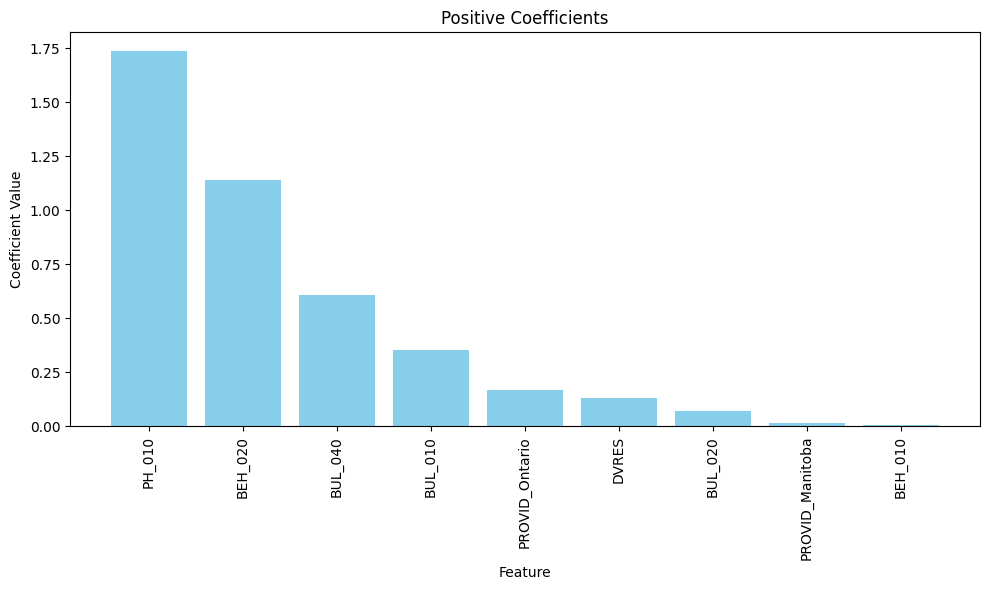

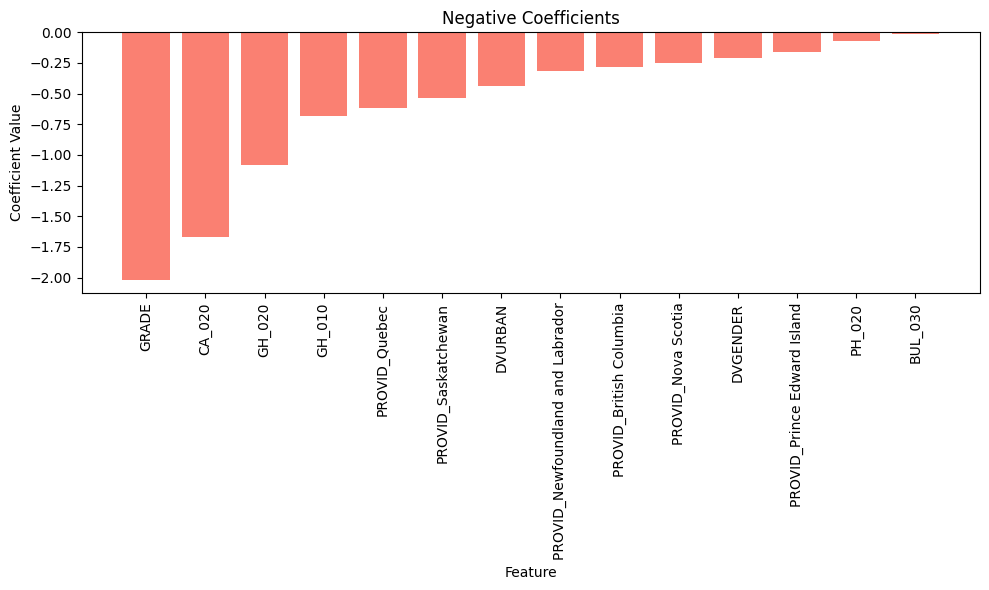

In [ ]:
# Separate positive and negative coefficients
positive_coefficients = coefficients_sorted[coefficients_sorted['Coefficient'] > 0]
negative_coefficients = coefficients_sorted[coefficients_sorted['Coefficient'] < 0]

# Create the bar plot for positive coefficients
plt.figure(figsize=(10, 6))
plt.bar(positive_coefficients['Feature'], positive_coefficients['Coefficient'], color='skyblue')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.title('Positive Coefficients')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Create the bar plot for negative coefficients
plt.figure(figsize=(10, 6))
plt.bar(negative_coefficients['Feature'], negative_coefficients['Coefficient'], color='salmon')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.title('Negative Coefficients')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
# prompt: Identify major factors to predict DVTY1ST for df_smoking

import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif


smoking_IV = ['GRADE', 'DVGENDER', 'DVURBAN', 'DVRES', 'GH_010', 'GH_020', 'PH_010', 'PH_020', 'CA_020', 'BEH_010', 'BEH_020', 'BUL_010', 'BUL_020', 'BUL_030', 'BUL_040']

# Define features (X) and target (y)
X = df[smoking_IV]
y = df['TS_011']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Handle potential missing values in X (replace with mean for numerical, mode for categorical)
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col].fillna(X[col].mean(), inplace=True)
    else:
        X[col].fillna(X[col].mode()[0], inplace=True)

# Use SelectKBest to find the top k features
selector = SelectKBest(score_func=f_classif, k=10) # Select top 10 features
X_new = selector.fit_transform(X, y)

# Get the indices of the selected features
selected_feature_indices = selector.get_support(indices=True)

# Get the names of the selected features
selected_feature_names = X.columns[selected_feature_indices]

# Print the selected features
print("Selected features for DVTY1ST prediction:")
selected_feature_names

Selected features for DVTY1ST prediction:


<ipython-input-10-3f633e8812a4>:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].mean(), inplace=True)


Index(['GRADE', 'GH_010', 'GH_020', 'PH_010', 'PH_020', 'CA_020', 'BEH_010',
       'BEH_020', 'BUL_030', 'BUL_040'],
      dtype='object')

In [ ]:

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression

# Assuming df_smoking is already created as in the previous code
# ... (previous code)

# Define features (X) and target variable (y)
X = df[['GRADE', 'DVGENDER', 'DVURBAN', 'DVRES', 'GH_010', 'GH_020', 'PH_010', 'PH_020', 'CA_020',
       'BEH_010', 'BEH_020', 'BUL_010', 'BUL_040']]
y = df['TS_011']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Handle potential missing values in X
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col].fillna(X[col].mean(), inplace=True)
    else:
        X[col].fillna(X[col].mode()[0], inplace=True)

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)

# Get coefficients and p-values
coefficients = model.coef_
p_values = f_regression(X, y)[1]

r2=model.score(X, y)
print(f"R-squared: {r2}")

# Create a DataFrame to display results
results_df = pd.DataFrame({'Variable': X.columns, 'Coefficient': coefficients, 'P-value': p_values})

# Display the results
results_df



<ipython-input-12-96895aa10884>:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].mean(), inplace=True)


R-squared: 0.15896231579262188


,Variable,Coefficient,P-value
0,GRADE,-0.102987,0.000000e+00
1,DVGENDER,-0.004549,1.779591e-04
2,DVURBAN,-0.021744,8.241873e-33
3,DVRES,0.008994,5.863278e-16
4,GH_010,-0.041055,4.090413e-294
5,GH_020,-0.100352,0.000000e+00
6,PH_010,0.117593,0.000000e+00
7,PH_020,0.032342,8.743554e-175
8,CA_020,-0.110435,0.000000e+00
9,BEH_010,0.020808,4.261926e-242


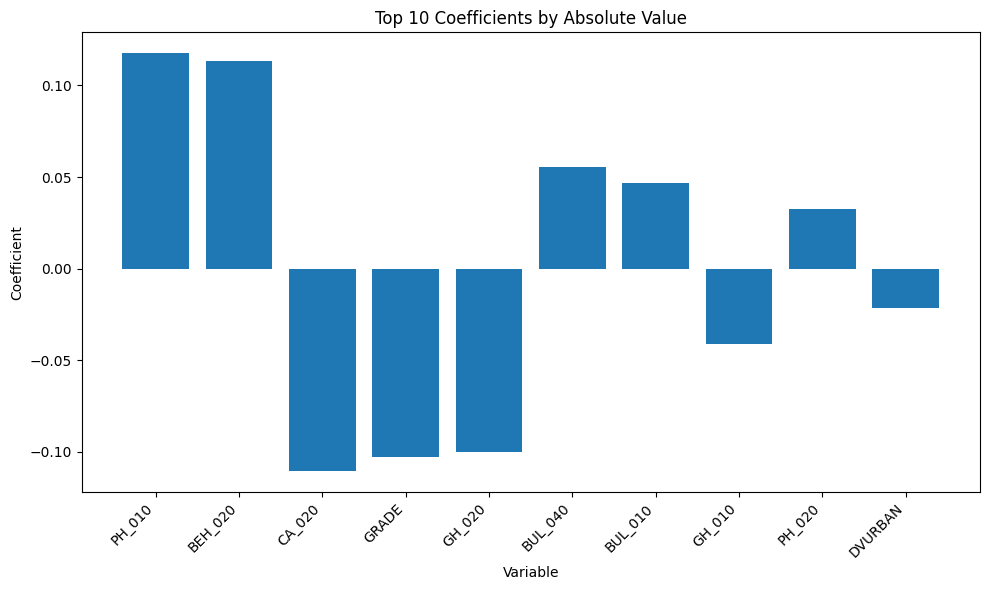

In [ ]:
# Sort by absolute value of the coefficient
top_10_coefficients = results_df.reindex(results_df['Coefficient'].abs().sort_values(ascending=False).index).head(10)

# Create a bar chart of the top 10 absolute coefficients
plt.figure(figsize=(10, 6))
plt.bar(top_10_coefficients['Variable'], top_10_coefficients['Coefficient'])
plt.xlabel('Variable')
plt.ylabel('Coefficient')
plt.title('Top 10 Coefficients by Absolute Value')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

#Predict Alcohol Drinking

In [ ]:
# Select variables related to Alcohol Drinking
alcohol_variables = ['PROVID', 'GRADE', 'DVGENDER', 'DVURBAN', 'DVRES', 'ALC_010', 'ALC_020', 'GH_010', 'GH_020', 'PH_110', 'PH_120', 'ALC_080', 'BEH_010', 'BEH_020', 'BUL_010', 'BUL_020', 'BUL_030', 'BUL_040']
df_alcohol = df[alcohol_variables]

# Display the new DataFrame
display(df_alcohol.head())

,PROVID,GRADE,DVGENDER,DVURBAN,DVRES,ALC_010,ALC_020,GH_010,GH_020,PH_110,PH_120,ALC_080,BEH_010,BEH_020,BUL_010,BUL_020,BUL_030,BUL_040
0,Prince Edward Island,0.4,1.0,0.0,1.0,1.0,0.00,0.25,0.5,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,1.0,1.0
1,Quebec,0.6,0.0,0.0,0.0,1.0,0.00,0.50,0.5,0.666667,1.000000,1.000000,0.666667,1.0,1.0,1.0,1.0,1.0
2,Newfoundland and Labrador,0.0,1.0,0.0,0.0,1.0,0.00,0.25,0.0,0.333333,0.666667,0.666667,1.000000,1.0,1.0,1.0,1.0,1.0
3,Nova Scotia,0.2,1.0,1.0,0.0,0.0,0.25,0.75,1.0,0.000000,0.666667,1.000000,1.000000,1.0,0.0,1.0,1.0,1.0
4,Newfoundland and Labrador,0.0,0.0,1.0,0.0,1.0,0.00,0.25,0.5,0.333333,0.666667,0.666667,1.000000,1.0,1.0,1.0,1.0,1.0


Accuracy of the logistic regression model: 0.719721767594108
Mean Squared Error: 0.280278232405892


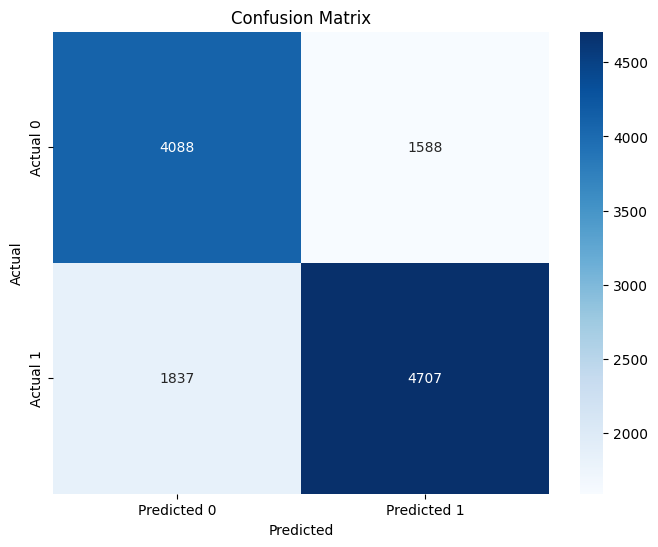

,Feature,Coefficient
0,GRADE,-2.464081
1,DVGENDER,-0.039564
2,DVURBAN,-0.331552
3,DVRES,0.268702
4,GH_010,0.144168
5,GH_020,-0.985349
6,PH_110,1.121511
7,PH_120,0.410297
8,ALC_080,-1.554067
9,BEH_010,-0.214466


In [ ]:
alcohol_variables = ['PROVID', 'GRADE', 'DVGENDER', 'DVURBAN', 'DVRES', 'ALC_010', 'ALC_020', 'GH_010', 'GH_020', 'PH_110', 'PH_120', 'ALC_080', 'BEH_010', 'BEH_020', 'BUL_010', 'BUL_020', 'BUL_030', 'BUL_040']

# Define features (X) and target (y)
X = df[alcohol_variables].drop(columns=['ALC_010', 'ALC_020'])
y = df['ALC_010']

X = pd.get_dummies(X, drop_first=True) #Using pandas get_dummies function

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


# Initialize and train a logistic regression model (you can change this to another model)
model = LogisticRegression(max_iter=1000, random_state=42) # increased max_iter
model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the logistic regression model: {accuracy}")

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")


# Evaluate the model using a confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Get the coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coefficients

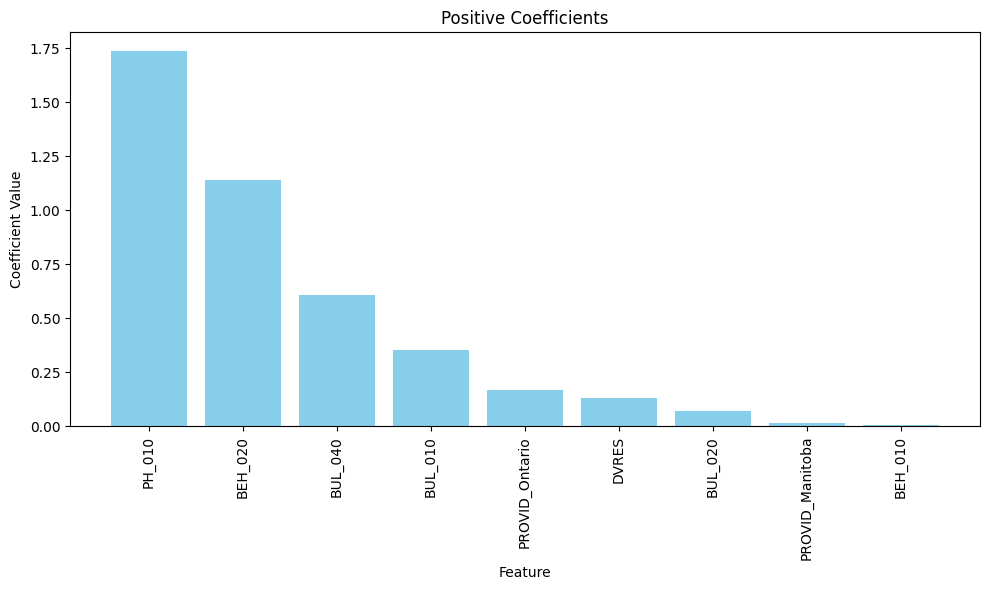

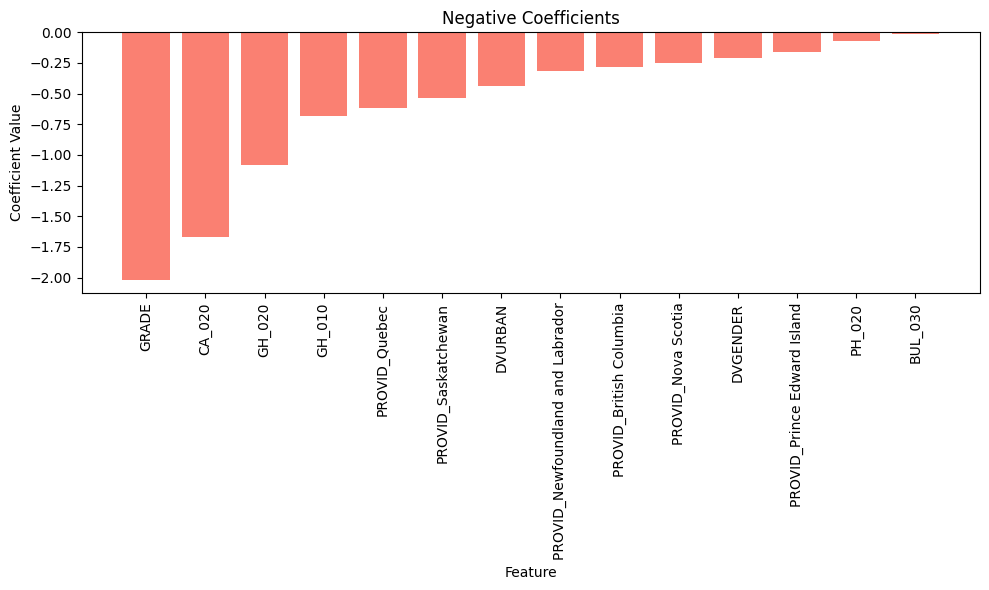

In [ ]:
# Separate positive and negative coefficients
positive_coefficients = coefficients_sorted[coefficients_sorted['Coefficient'] > 0]
negative_coefficients = coefficients_sorted[coefficients_sorted['Coefficient'] < 0]

# Create the bar plot for positive coefficients
plt.figure(figsize=(10, 6))
plt.bar(positive_coefficients['Feature'], positive_coefficients['Coefficient'], color='skyblue')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.title('Positive Coefficients')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Create the bar plot for negative coefficients
plt.figure(figsize=(10, 6))
plt.bar(negative_coefficients['Feature'], negative_coefficients['Coefficient'], color='salmon')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.title('Negative Coefficients')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:

alcohol_variables = ['PROVID', 'GRADE', 'DVGENDER', 'DVURBAN', 'DVRES', 'ALC_010', 'ALC_020', 'GH_010', 'GH_020', 'PH_110', 'PH_120', 'ALC_080','BUL_010', 'BUL_020', 'BUL_030', 'BUL_040']

# Define features (X) and target (y)
X = df[alcohol_variables].drop(columns=['ALC_010', 'ALC_020'])
y = df['ALC_020']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Handle potential missing values in X (replace with mean for numerical, mode for categorical)
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col].fillna(X[col].mean(), inplace=True)
    else:
        X[col].fillna(X[col].mode()[0], inplace=True)

# Use SelectKBest to find the top k features
selector = SelectKBest(score_func=f_classif, k=10) # Select top 10 features
X_new = selector.fit_transform(X, y)

# Get the indices of the selected features
selected_feature_indices = selector.get_support(indices=True)

# Get the names of the selected features
selected_feature_names = X.columns[selected_feature_indices]

# Print the selected features
print("Selected features for ALC_020 prediction:")
selected_feature_names

Selected features for ALC_020 prediction:


<ipython-input-18-d9f3f1e980ee>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].mean(), inplace=True)


Index(['GRADE', 'DVGENDER', 'DVRES', 'GH_020', 'PH_110', 'PH_120', 'ALC_080',
       'BUL_010', 'BUL_030', 'BUL_040'],
      dtype='object')

<ipython-input-32-97aedb1c36a0>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].mean(), inplace=True)
<ipython-input-32-97aedb1c36a0>:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

R-squared: 0.23425659229888884
                            Variable  Coefficient        P-value
0                            DVURBAN     0.234346   7.592723e-13
1                              GRADE     0.382694   0.000000e+00
2                           DVGENDER    -0.014252   9.374269e-16
3                              DVRES    -0.098901   3.630413e-46
4                             GH_020     0.118473   0.000000e+00
5                             PH_110    -0.137400   0.000000e+00
6                             PH_120    -0.192402  5.164053e-163
7                            ALC_080     0.312645   0.000000e+00
8                            BUL_010    -0.284079   1.849661e-27
9                            BUL_030    -0.036439   4.812707e-56
10                           BUL_040    -0.403646  1.310436e-122
11           PROVID_British Columbia     0.224768   7.797771e-03
12                   PROVID_Manitoba     0.062349   4.008704e-48
13  PROVID_Newfoundland and Labrador     0.263682   1.29790

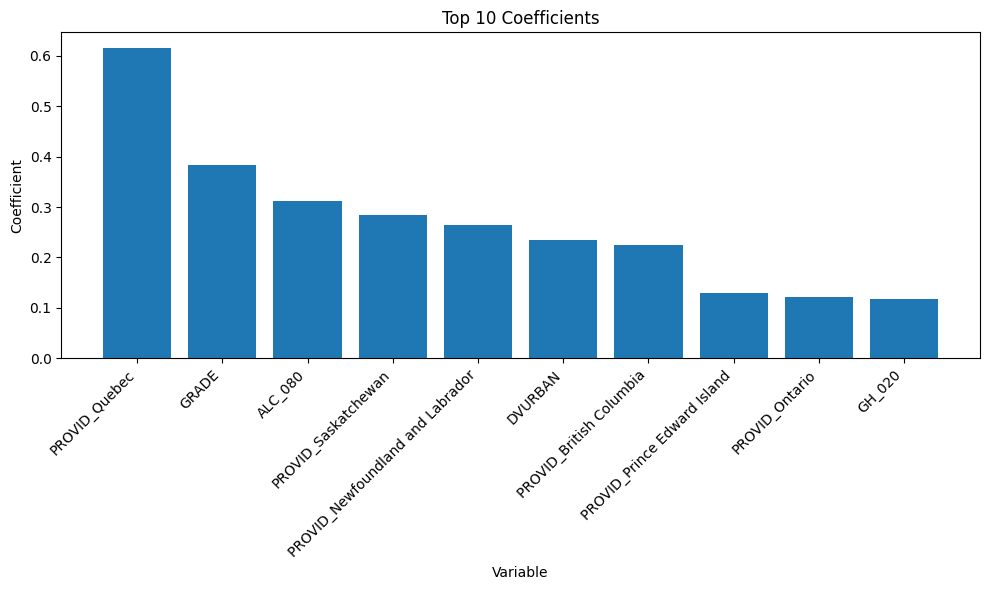

In [ ]:
# Define features (X) and target variable (y)
X = df[['PROVID', 'DVURBAN', 'GRADE', 'DVGENDER', 'DVRES', 'GH_020', 'PH_110', 'PH_120', 'ALC_080',
       'BUL_010', 'BUL_030', 'BUL_040']]
y = df['ALC_020']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Handle potential missing values in X
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col].fillna(X[col].mean(), inplace=True)
    else:
        X[col].fillna(X[col].mode()[0], inplace=True)

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)

# Get coefficients and p-values
coefficients = model.coef_
p_values = f_regression(X, y)[1]

r2=model.score(X, y)
print(f"R-squared: {r2}")

# Create a DataFrame to display results
results_df = pd.DataFrame({'Variable': X.columns, 'Coefficient': coefficients, 'P-value': p_values})

print(results_df)

# Define features (X) and target variable (y)
X = df[['PROVID', 'DVURBAN', 'GRADE', 'DVGENDER', 'DVRES', 'GH_020', 'PH_110', 'PH_120', 'ALC_080',
       'BUL_010', 'BUL_030', 'BUL_040']]
y = df['ALC_020']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Handle potential missing values in X
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col].fillna(X[col].mean(), inplace=True)
    else:
        X[col].fillna(X[col].mode()[0], inplace=True)

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)

# Get coefficients and p-values
coefficients = model.coef_
p_values = f_regression(X, y)[1]

r2=model.score(X, y)
print(f"R-squared: {r2}")

# Create a DataFrame to display results
results_df = pd.DataFrame({'Variable': X.columns, 'Coefficient': coefficients, 'P-value': p_values})


# Sort the coefficients by absolute value and get the top 10

top_10_coefficients = results_df.sort_values(by='Coefficient', ascending=False).head(10)
# Create a bar chart of the top 10 coefficients
plt.figure(figsize=(10, 6))
plt.bar(top_10_coefficients['Variable'], top_10_coefficients['Coefficient'])
plt.xlabel('Variable')
plt.ylabel('Coefficient')
plt.title('Top 10 Coefficients')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


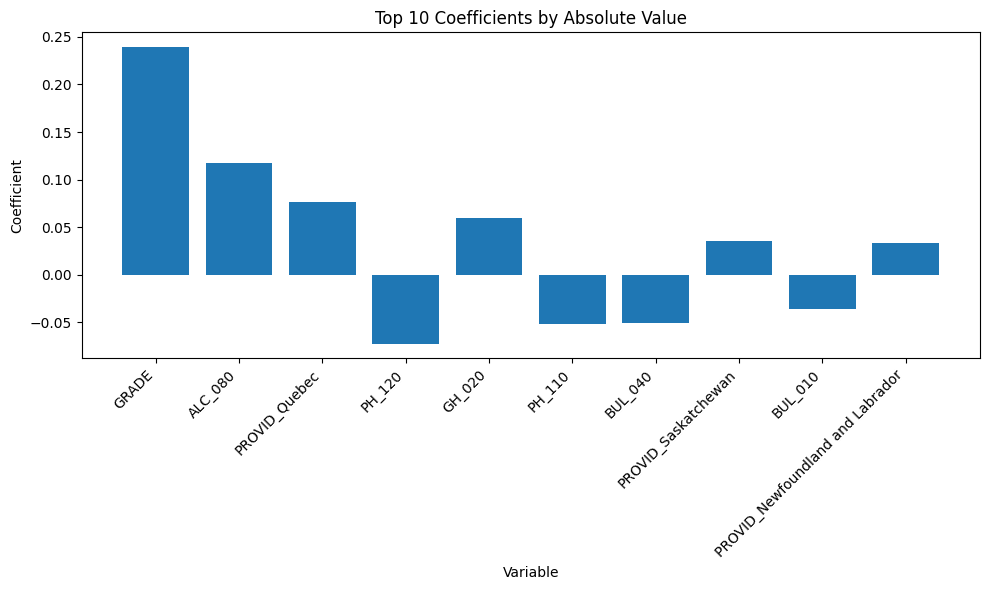

In [ ]:
# prompt: top ten coefficients by absolute value

import matplotlib.pyplot as plt
# Sort by absolute value of the coefficient
top_10_coefficients = results_df.reindex(results_df['Coefficient'].abs().sort_values(ascending=False).index).head(10)

# Create a bar chart of the top 10 absolute coefficients
plt.figure(figsize=(10, 6))
plt.bar(top_10_coefficients['Variable'], top_10_coefficients['Coefficient'])
plt.xlabel('Variable')
plt.ylabel('Coefficient')
plt.title('Top 10 Coefficients by Absolute Value')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


In [ ]:
print(results_df)


                            Variable  Coefficient        P-value
0                            DVURBAN     0.029293   7.592723e-13
1                              GRADE     0.239183   0.000000e+00
2                           DVGENDER    -0.001782   9.374269e-16
3                              DVRES    -0.024725   3.630413e-46
4                             GH_020     0.059237   0.000000e+00
5                             PH_110    -0.051525   0.000000e+00
6                             PH_120    -0.072151  5.164053e-163
7                            ALC_080     0.117242   0.000000e+00
8                            BUL_010    -0.035510   1.849661e-27
9                            BUL_030    -0.004555   4.812707e-56
10                           BUL_040    -0.050456  1.310436e-122
11           PROVID_British Columbia     0.028096   7.797771e-03
12                   PROVID_Manitoba     0.007794   4.008704e-48
13  PROVID_Newfoundland and Labrador     0.032960   1.297903e-26
14                PROVID_

#Predict Cannabis Behavior

In [ ]:
# Select variables related to Cannabis
cannabis_variables = ['PROVID', 'GRADE', 'DVGENDER', 'DVURBAN', 'DVRES', 'CAN_010', 'CAN_020', 'CAN_130', 'GH_010', 'GH_020', 'PH_070', 'PH_080', 'CAN_050', 'BEH_010', 'BEH_020', 'BUL_010', 'BUL_020', 'BUL_030', 'BUL_040']
df_cannabis = df[cannabis_variables]

# Display the new DataFrame
display(df_cannabis.head())

,PROVID,GRADE,DVGENDER,DVURBAN,DVRES,CAN_010,CAN_020,CAN_130,GH_010,GH_020,PH_070,PH_080,CAN_050,BEH_010,BEH_020,BUL_010,BUL_020,BUL_030,BUL_040
0,Prince Edward Island,9,2,1,3,2,1,1,2,3,1,1,1,1,1,2,1,2,2
1,Quebec,10,1,1,1,2,1,1,3,3,3,4,4,3,4,2,2,2,2
2,Newfoundland and Labrador,7,2,1,1,2,1,1,2,1,2,3,2,4,4,2,2,2,2
3,Nova Scotia,8,2,2,1,2,1,1,4,5,2,3,3,4,4,1,2,2,2
4,Newfoundland and Labrador,7,1,2,1,2,1,1,2,3,2,4,2,4,4,2,2,2,2


Accuracy of the logistic regression model: 0.8819148936170212
Mean Squared Error: 0.11808510638297873


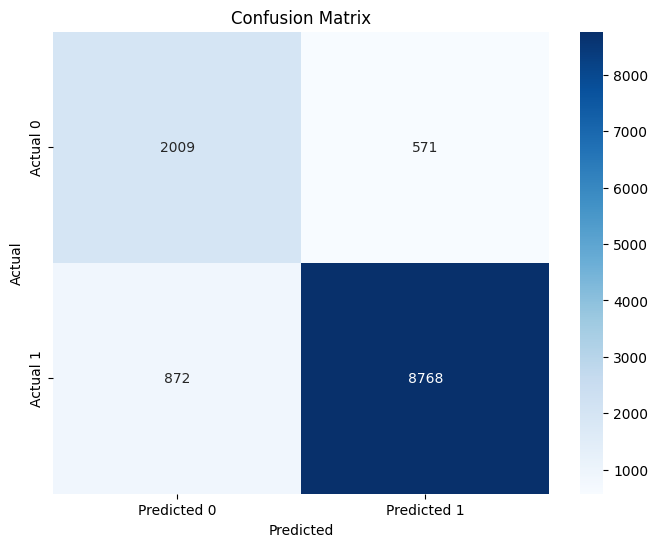

,Feature,Coefficient
0,GRADE,-0.327301
1,DVGENDER,0.432981
2,DVURBAN,0.206476
3,DVRES,0.280973
4,CAN_130,-2.556629
5,GH_010,0.025164
6,GH_020,-0.096132
7,PH_070,0.725615
8,PH_080,-0.025005
9,CAN_050,-0.487486


In [ ]:
# Define features (X) and target (y)
X = df[cannabis_variables].drop(columns=['CAN_010', 'CAN_020'])
y = df['CAN_010']

X = pd.get_dummies(X, drop_first=True) #Using pandas get_dummies function

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


# Initialize and train a logistic regression model (you can change this to another model)
model = LogisticRegression(max_iter=1000, random_state=42) # increased max_iter
model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the logistic regression model: {accuracy}")

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")


# Evaluate the model using a confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Get the coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coefficients

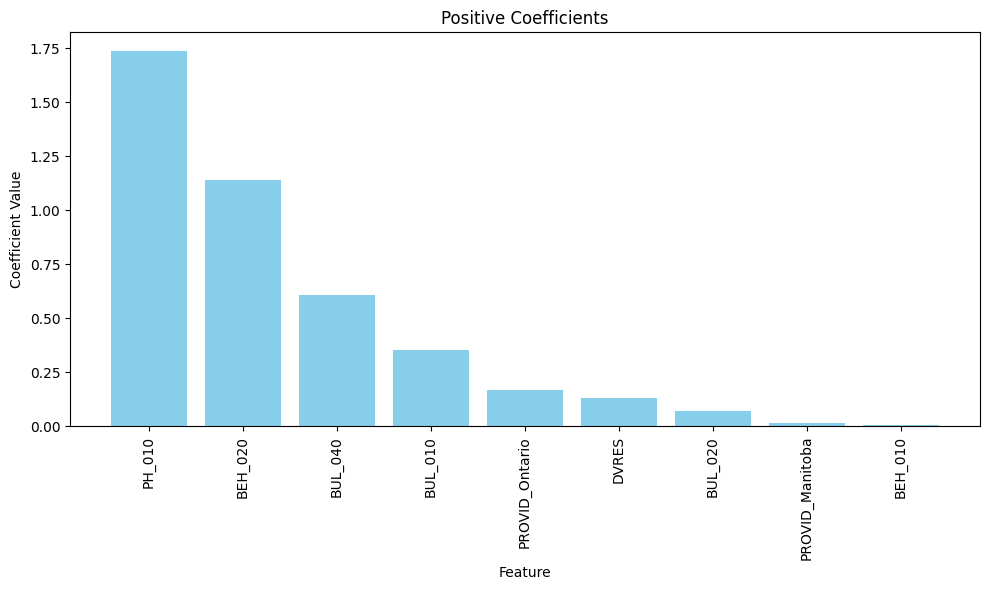

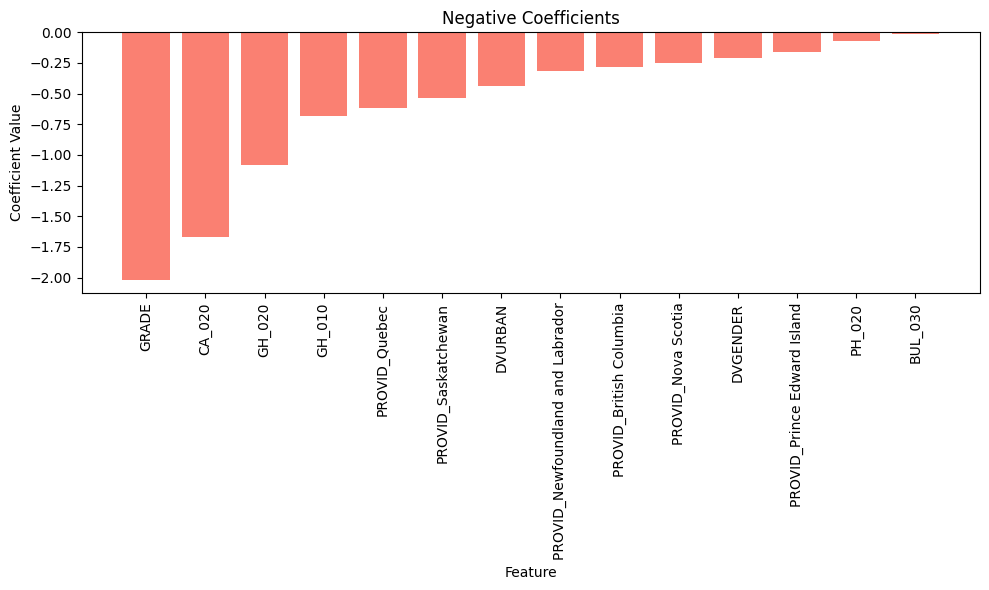

In [ ]:
# Separate positive and negative coefficients
positive_coefficients = coefficients_sorted[coefficients_sorted['Coefficient'] > 0]
negative_coefficients = coefficients_sorted[coefficients_sorted['Coefficient'] < 0]

# Create the bar plot for positive coefficients
plt.figure(figsize=(10, 6))
plt.bar(positive_coefficients['Feature'], positive_coefficients['Coefficient'], color='skyblue')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.title('Positive Coefficients')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Create the bar plot for negative coefficients
plt.figure(figsize=(10, 6))
plt.bar(negative_coefficients['Feature'], negative_coefficients['Coefficient'], color='salmon')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.title('Negative Coefficients')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:

# Define features (X) and target (y)
X = df[cannabis_variables].drop(columns=['CAN_010', 'CAN_020'])
y = df['CAN_020']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Handle potential missing values in X (replace with mean for numerical, mode for categorical)
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col].fillna(X[col].mean(), inplace=True)
    else:
        X[col].fillna(X[col].mode()[0], inplace=True)

# Use SelectKBest to find the top k features
selector = SelectKBest(score_func=f_classif, k=10) # Select top 10 features
X_new = selector.fit_transform(X, y)

# Get the indices of the selected features
selected_feature_indices = selector.get_support(indices=True)

# Get the names of the selected features
selected_feature_names = X.columns[selected_feature_indices]

# Print the selected features
print("Selected features for CAN_020 prediction:")
selected_feature_names

Selected features for CAN_020 prediction:


<ipython-input-23-87dde4a1ed6d>:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].mean(), inplace=True)


Index(['GRADE', 'CAN_130', 'GH_010', 'GH_020', 'PH_070', 'PH_080', 'CAN_050',
       'BEH_010', 'BEH_020', 'BUL_040'],
      dtype='object')

<ipython-input-37-cd91bdf1c4f1>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].mean(), inplace=True)


R-squared: 0.4730205779838683
               Variable  Coefficient        P-value
3               CAN_130     1.269739   0.000000e+00
10              BEH_020    -0.377955   0.000000e+00
8               CAN_050     0.211180   0.000000e+00
11              BUL_040    -0.178202  3.955450e-150
9               BEH_010     0.097163  1.003172e-146
6                PH_070    -0.088590   0.000000e+00
7                PH_080    -0.086389   0.000000e+00
19  PROVID_Saskatchewan     0.081136   1.146571e-02
5                GH_020     0.065505   0.000000e+00
2                 GRADE     0.064518   0.000000e+00


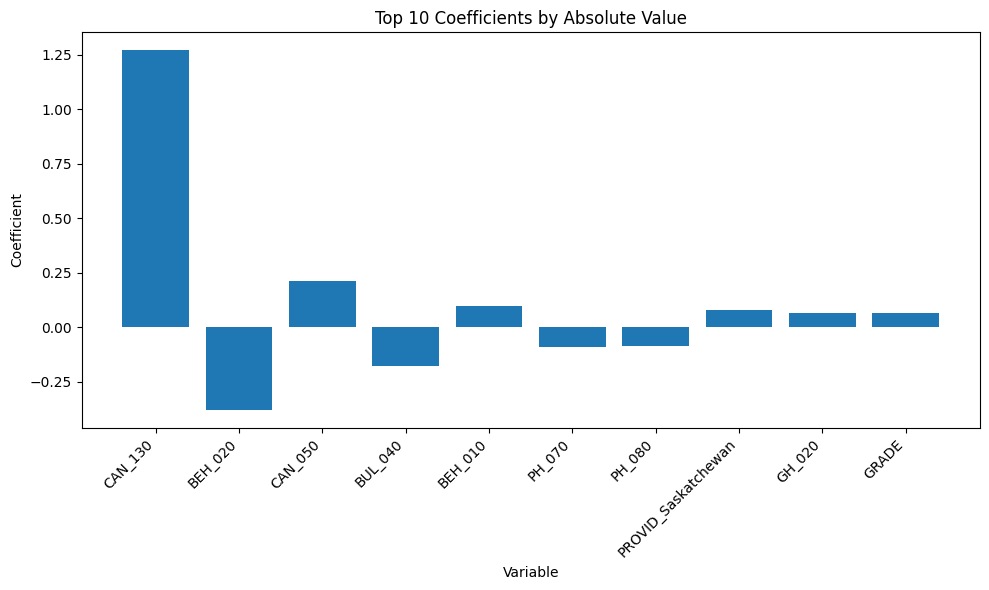

In [ ]:
# Define features (X) and target variable (y)
X = df[['DVGENDER', 'DVURBAN', 'PROVID', 'GRADE', 'CAN_130', 'GH_010', 'GH_020', 'PH_070', 'PH_080', 'CAN_050',
       'BEH_010', 'BEH_020', 'BUL_040']]
y = df['CAN_020']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Handle potential missing values in X
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col].fillna(X[col].mean(), inplace=True)
    else:
        X[col].fillna(X[col].mode()[0], inplace=True)

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)

# Get coefficients and p-values
coefficients = model.coef_
p_values = f_regression(X, y)[1]

r2=model.score(X, y)
print(f"R-squared: {r2}")

# Create a DataFrame to display results
results_df = pd.DataFrame({'Variable': X.columns, 'Coefficient': coefficients, 'P-value': p_values})



# Sort by absolute value of the coefficient
top_10_coefficients = results_df.reindex(results_df['Coefficient'].abs().sort_values(ascending=False).index).head(10)

print(top_10_coefficients)
# Create a bar chart of the top 10 absolute coefficients
plt.figure(figsize=(10, 6))
plt.bar(top_10_coefficients['Variable'], top_10_coefficients['Coefficient'])
plt.xlabel('Variable')
plt.ylabel('Coefficient')
plt.title('Top 10 Coefficients by Absolute Value')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()